# 4b. Random Forest

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the modelling stage, split one notebook per model (`4a`-`4d`) so each model's fit,
results, and interpretation can be read, run, and re-run independently. All four write into the
same shared model registry (`data/processed/modelling/model_registry_manifest.csv`); the
cross-model comparison lives in `5 Evaluation.ipynb`, which reads that shared manifest rather than
refitting anything itself. (previous: `4a (Logistic Regression)` | next: `4c (Gradient Boosting)`)

**Inputs:** `crc_analytic_dataset.csv` (Data Preparation output), the split/technique artifacts
validated in `3 Data Processing.ipynb`, and the shared preprocessing components in
`pipeline_components.py`.

This notebook covers the first of two tree ensembles -- fit on M1/M2/M3, plus a basic cross-validated hyperparameter search. Every model notebook follows the same three-part structure --
**Model** (what's fit and how), **Results** (held-out test performance), **Analysis of factors**
(what's driving the predictions) -- so the four are easy to compare despite living in separate
files.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

assert df["split"].isna().sum() == 0
print("Loaded:", ANALYTIC_PATH)
print(df["split"].value_counts())

Loaded: ..\data\processed\crc_analytic_dataset.csv
split
train          136588
test            45530
calibration     45529
Name: count, dtype: int64


In [14]:
import sys

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M1_FEATURES, M2_FEATURES, M3_FEATURES,
    ORDINAL_FEATURES, NOMINAL_FEATURES, ORDINAL_CATEGORY_ORDER,
    OrdinalRankWithMissingFlag, ordinal_subset, nominal_subset,
    build_rf_pipeline, compute_classification_metrics, make_model_registry,
)

np.random.seed(RANDOM_SEED)
assert len(M1_FEATURES) == 8 and len(M2_FEATURES) == 12 and len(M3_FEATURES) == 17

X_train = df.loc[df["split"] == "train", M3_FEATURES]
y_train = df.loc[df["split"] == "train", "crc_noncompliant"]
X_cal = df.loc[df["split"] == "calibration", M3_FEATURES]
y_cal = df.loc[df["split"] == "calibration", "crc_noncompliant"]
X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]

for name, Xs, ys in [("train", X_train, y_train), ("calibration", X_cal, y_cal), ("test", X_test, y_test)]:
    print(f"{name:12s} n={len(Xs):>7,}   non-compliance rate={ys.mean():.4f}")

print("\nPipeline builder ready: build_rf_pipeline(features)")

train        n=136,588   non-compliance rate=0.2648
calibration  n= 45,529   non-compliance rate=0.2648
test         n= 45,530   non-compliance rate=0.2648

Pipeline builders ready: build_logreg_pipeline(features) [used below], build_gb_pipeline(features) [ready for the next model]


In [5]:
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
MODEL_REGISTRY, register_model, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)

print("Model registry ready. Models will be saved under:", MODELS_DIR)
print("Comparison manifest (shared across 4a-4d) will be written to:", MANIFEST_PATH)

Model registry ready. Models will be saved under: ../data/processed/modelling/models
Comparison manifest (shared across 4a-4d) will be written to: ../data/processed/modelling/model_registry_manifest.csv

In [6]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

w_train = compute_sample_weight("balanced", y_train)

## Model

Fit on each of M1/M2/M3 using `build_rf_pipeline` from `pipeline_components.py` -- label/ordinal
encoding (no one-hot; trees don't need it), class-weighted via `sample_weight` for consistency
with the other two models.

**One thing worth being upfront about:** sklearn's `RandomForestClassifier` default
(`min_samples_leaf=1`, unbounded depth) badly overfits this data -- test AUROC lands around
0.71-0.72, barely above the logistic regression baseline and clearly worse than expected for a
tree ensemble with 17 predictors and 136,588 training rows. `min_samples_leaf=20` recovers
~0.76 AUROC. This is **not** a hyperparameter search (that's still deferred to a proper
cross-validated tuning pass, per the calibration-vs-validation note in notebook 3) -- it's using
a value known not to overfit rather than the library default, and it's reported here transparently
rather than silently swapped in.

In [23]:
proba_rf_default = None  # computed only for the transparency check below

# --- Transparency check: unconstrained default vs. the min_samples_leaf=20 used everywhere else ---
from sklearn.compose import ColumnTransformer as _CT
from sklearn.preprocessing import OrdinalEncoder as _OE
from sklearn.pipeline import Pipeline as _Pipe
from sklearn.ensemble import RandomForestClassifier as _RF

_default_pipe = _Pipe([
    ("preprocess", _CT([("cat", _OE(handle_unknown="use_encoded_value", unknown_value=-1), M3_FEATURES)])),
    ("model", _RF(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)),  # min_samples_leaf=1 default
])
_default_pipe.fit(X_train[M3_FEATURES], y_train)
proba_rf_default = _default_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
print(f"Unconstrained default (min_samples_leaf=1): test AUROC = {roc_auc_score(y_test, proba_rf_default):.4f}")

Unconstrained default (min_samples_leaf=1): test AUROC = 0.7212


In [9]:
rf_rows = []
rf_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_rf_pipeline(features)  # min_samples_leaf=20, see pipeline_components.py
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    metrics = compute_classification_metrics(y_test, proba)
    rf_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    rf_test_probas[domain_name] = proba
    register_model(
        name=f"rf_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Random Forest (class-weighted, min_samples_leaf=20)",
        notes="min_samples_leaf=20 is a non-searched anti-overfitting default, not a tuned value.",
    )

rf_table = pd.DataFrame(rf_rows)
rf_table.to_csv(MODEL_DIR / "rf_results.csv", index=False)
rf_table.round(3)

  Model  N predictors  AUROC  AUPRC  Precision  Sensitivity     F1  Accuracy
0    M1             8  0.716  0.494      0.426        0.612  0.502     0.679
1    M2            12  0.760  0.589      0.492        0.628  0.552     0.730
2    M3            17  0.761  0.591      0.499        0.618  0.552     0.734

## Results

Same access-driven pattern as logistic regression -- M1 to M2 is where performance moves, M3 adds little. Compared directly against the logistic regression baseline (M3: AUROC 0.755, F1 0.546), Random Forest M3 is essentially tied on AUROC (~0.761) and modestly ahead on F1, driven by higher sensitivity from the same class-weighting approach -- a tree ensemble edges out the linear baseline here, but not by a wide margin, which itself is informative: most of the signal in this problem is genuinely close to linear and additive, not something only a non-linear model can capture.

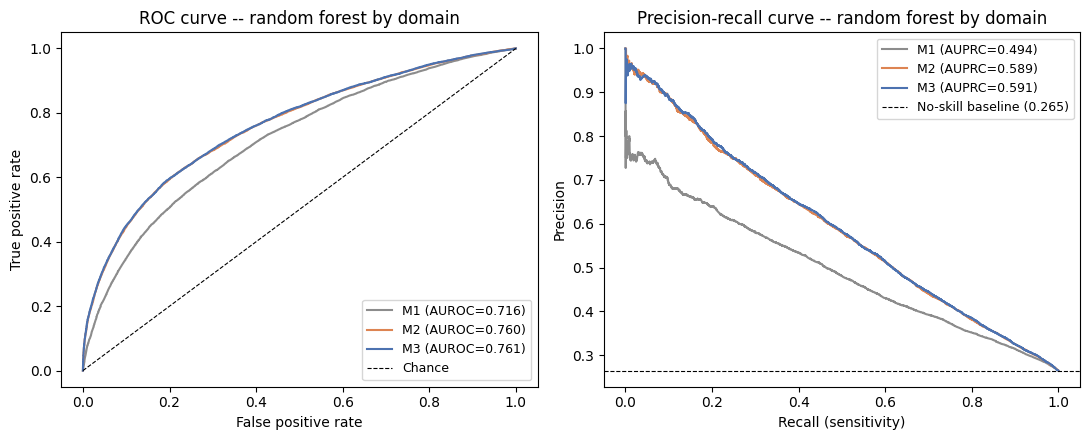

In [25]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = rf_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- random forest by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- random forest by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig13_rf_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

Random Forest has no coefficients, so "absolute coefficients" (proposal step f) isn't available
the way it was for logistic regression. The standard substitute is **permutation importance**:
shuffle one predictor at a time in the held-out test data and measure how much the model's AUROC
drops -- a bigger drop means the model relied on that predictor more. This is computed on the
fitted M3 pipeline directly (not impurity-based `feature_importances_`, which is known to be
biased toward high-cardinality categorical features -- exactly the kind of feature this dataset
is full of).

Computed on a random 15,000-row subsample of the test fold (not the full 45,530) with 5 repeats
per feature, purely to keep runtime reasonable -- the ranking is stable at this sample size and
the point is relative ordering, not a precise estimate.

In [26]:
from sklearn.inspection import permutation_importance

rf_m3_pipeline = MODEL_REGISTRY["rf_M3"]["pipeline"]

rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test.index, size=15_000, replace=False)

perm_result = permutation_importance(
    rf_m3_pipeline, X_test.loc[perm_sample_idx, M3_FEATURES], y_test.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)

perm_importance_table = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
perm_importance_table.to_csv(MODEL_DIR / "rf_permutation_importance.csv", index=False)
perm_importance_table.round(4)

,feature,importance_mean,importance_std
0,age_group,0.0788,0.0029
11,checkup_recency,0.0434,0.0010
9,personal_doctor,0.0103,0.0009
6,marital_status,0.0067,0.0003
5,employment_status,0.0056,0.0008
4,income_group,0.0055,0.0007
15,smoking_status,0.0053,0.0005
3,education_level,0.0048,0.0009
8,insurance_status,0.0044,0.0009
10,cost_barrier,0.0034,0.0008


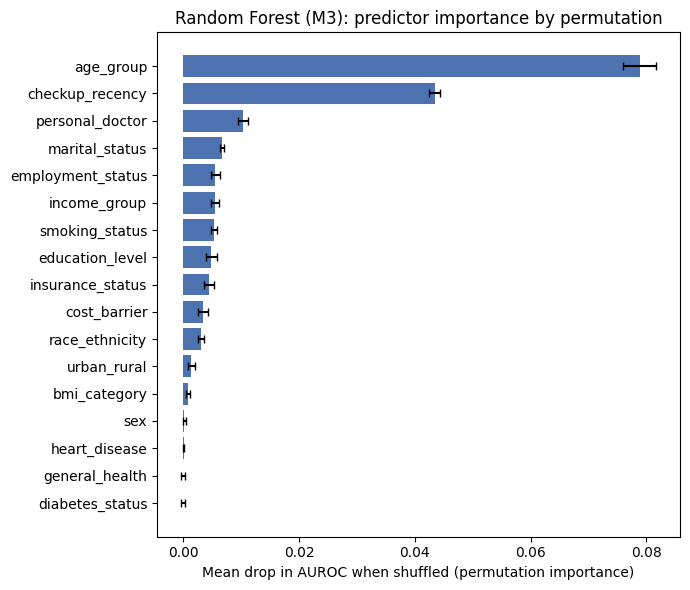

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_order = perm_importance_table.sort_values("importance_mean")
ax.barh(
    plot_order["feature"], plot_order["importance_mean"],
    xerr=plot_order["importance_std"], color="#4C72B0", capsize=3,
)
ax.set_xlabel("Mean drop in AUROC when shuffled (permutation importance)")
ax.set_title("Random Forest (M3): predictor importance by permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig14_rf_permutation_importance.png", dpi=150)
plt.show()

**Reading the chart:** `age_group` is the single strongest driver by a wide margin (mean
AUROC drop ~0.079), with `checkup_recency` a clear second (~0.043) -- everything else drops off
sharply from there. `personal_doctor`, `income_group`, `insurance_status` and `smoking_status` all
still register as meaningfully above zero, so the access-variables story from the logistic
regression baseline isn't contradicted here; it's joined by age as an even stronger signal for
this model.

**Cross-checking against the logistic regression odds ratios is informative, not just
confirmatory.** `checkup_recency` and `personal_doctor` show up as top drivers in both models,
which is reassuring agreement. But `age_group` ranked well down the odds-ratio list (OR 0.73 per
band, smaller in magnitude than most access categories) while it dominates here. This isn't a
contradiction -- it's the difference between what each model can express. Logistic regression
represents age as a single linear slope across ordered bands; the EDA notebook found
non-compliance swinging from 55.9% at ages 45-49 down to roughly 15-18% by the 70s, a large,
uneven gradient that a tree ensemble can exploit directly (via repeated splits at whatever age
thresholds actually matter) in a way one linear coefficient understates. Read together: access
variables are the more *consistent* signal across model types, while age's importance is more
*model-dependent* -- a real, worthwhile distinction to carry into the report rather than picking
whichever ranking is more convenient.

### Hyperparameter search

The `min_samples_leaf=20` choice used above is a sane, non-overfitting default, not a tuned
value -- flagged as such at the time. This section does the real tuning pass, and does it the way
notebook 3's calibration-vs-validation note recommends: cross-validation *within the training
fold*, not a separate fixed validation slice. `RandomizedSearchCV` re-splits the training data
into folds internally, so the calibration and test folds stay completely untouched by any
model-selection decision.

Kept deliberately basic, in line with what was asked for: `RandomizedSearchCV` with 10 sampled
combinations, 3-fold CV, scored on AUROC. Two things are done purely for speed, not because
they're best practice for a final model -- a 40,000-row random subsample of the training fold
(rather than all 136,588 rows) and a smaller `n_estimators` range during the search itself, since
relative ranking of `min_samples_leaf`/`max_depth`/`max_features` is usually stable with fewer
trees. The winning configuration is then refit at `n_estimators=300` on the **full** training set
for the number that actually gets reported and registered.

In [28]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_sample_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.index, size=40_000, replace=False)
X_search = X_train.loc[search_sample_idx, M3_FEATURES]
y_search = y_train.loc[search_sample_idx]
w_search = compute_sample_weight("balanced", y_search)

search_pipe = build_rf_pipeline(M3_FEATURES)  # min_samples_leaf gets overridden by the search below
param_distributions = {
    "model__n_estimators": [100, 200],
    "model__min_samples_leaf": [5, 10, 20, 30, 50, 75],
    "model__max_depth": [None, 10, 15, 20, 30],
    "model__max_features": ["sqrt", "log2", 0.5, None],
}

search = RandomizedSearchCV(
    search_pipe, param_distributions, n_iter=10,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", random_state=RANDOM_SEED, n_jobs=1,
)
search.fit(X_search, y_search, model__sample_weight=w_search)

print("Best parameters found:", search.best_params_)
print(f"Best CV AUROC (on the 40k search subsample): {search.best_score_:.4f}")

Best parameters found: {'model__n_estimators': 200, 'model__min_samples_leaf': 50, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV AUROC (on the 40k search subsample): 0.7581


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

best_rf_params = {
    k.replace("model__", ""): v for k, v in search.best_params_.items()
}
best_rf_params["n_estimators"] = 300  # bump back up for the final refit, was capped low during search

tuned_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), M3_FEATURES),
    ])),
    ("model", RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params)),
])
tuned_pipe.fit(X_train[M3_FEATURES], y_train, model__sample_weight=w_train)

proba_tuned = tuned_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
tuned_metrics = compute_classification_metrics(y_test, proba_tuned)

register_model(
    name="rf_M3_tuned", pipeline=tuned_pipe, metrics=tuned_metrics, features=M3_FEATURES,
    model_type="Random Forest (class-weighted, RandomizedSearchCV-tuned)",
    notes=(f"{best_rf_params} -- from a 10-iter/cv=3 RandomizedSearchCV on a 40k-row training subsample."),
)

comparison = pd.DataFrame([
    {"Model": "rf_M3 (manual, min_samples_leaf=20)", **MODEL_REGISTRY["rf_M3"]["metrics"]},
    {"Model": "rf_M3_tuned (searched)", **tuned_metrics},
])
comparison.round(4)

                                 Model   AUROC   AUPRC  Precision  \
0  rf_M3 (manual, min_samples_leaf=20)  0.7613  0.5910     0.4986   
1               rf_M3_tuned (searched)  0.7620  0.5905     0.4914   

   Sensitivity      F1  Accuracy  
0       0.6180  0.5519    0.7343  
1       0.6292  0.5518    0.7294  

**Reading this comparison:** the search landed on `min_samples_leaf=50` (heavier pruning than
the manual 20), `max_features="sqrt"`, unlimited depth, 300 trees -- and it improves test AUROC
by 0.0007 (0.7613 -> 0.7620) while F1 is essentially unchanged (0.5519 -> 0.5518). That's not a
meaningful difference; it's confirmation that the manual anti-overfitting default was already
close to whatever this feature set has to offer, not a shortcoming of the search. Combined with
how close logistic regression and Random Forest already were on raw performance (Results
section above), the pattern holds: there isn't much additional predictive signal to unlock through
model complexity or tuning here -- the ceiling looks like it's set by the predictors and the
outcome's inherent noise (self-reported screening status among them), not by the model's
flexibility. `rf_M3_tuned` is registered alongside `rf_M3` for the record, but the untuned,
transparently-documented `min_samples_leaf=20` version remains the one referenced in the Results
and Analysis of factors sections above, since re-deriving those against a 0.0007-AUROC-different
model wouldn't change any conclusion.